**CAPSTONE PROJECT**

As a performance engineer, I want to build a predictive model that estimates system resource usage—such as CPU, memory, and thread utilization—based on the distribution of API usage within an application. Currently, predicting how different API load mixes will impact system resources requires extensive performance testing with multiple load distributions.

This project will use Linear Regression (and possibly other regression methods) to model the relationship between API usage patterns and resulting resource consumption. Given input data describing the percentage load distribution across different APIs, the model will predict the expected resource usage. This will help in capacity planning and reduce the need for repeated, costly performance testing scenarios.*

**PROBLEM STATEMENT AND APPROACH**

Can we accurately predict system resource utilization (CPU, memory, and thread usage) based on the percentage distribution of multiple API load's within an application using regression models?

**Expected Data Source**

JMeter load test executions Monitoring tool like Argus and Grafana

**Techniques to be used in Analysis**

Data Preparation: Clean, Normalize, Scaling etc.. Model Techniques: Linear regression as base model, Regularization using Lasso or Ridge, Polynomial Regression for non-linear features Metrics: Coef, MSE/RMSE, Cross-validation

**Expected Results**

The model should identify which APIs have the strongest impact on CPU and memory usage. Resource usage will likely increase linearly with certain APIs but may show nonlinear effects under high load. The model will allow estimation of system resource usage for new API load distributions without running new load tests.

**Why?**

Performance testing is expensive and time-consuming. Capacity planning today relies heavily on manual experiments. Predictive modeling can help Reduce Testing cycles and Support proactive scaling decisions

In [14]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, KFold, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.metrics import mean_squared_error, r2_score

In [15]:
# Load data
df = pd.read_csv("api_metrics_2h.csv")
df = df.sort_values("Timestamp")
df.head()

,Timestamp,api1_rps,api1_rt,api2_rps,api2_rt,api3_rps,api3_rt,api4_rps,api4_rt,api5_rps,api5_rt,cpu_usage,memory_usage,thread_usage
0,1771715528,81,81,88,84,57,118,64,114,78,73,1,2206,13
1,1771715529,54,160,45,160,41,178,44,157,56,148,9,3879,98
2,1771715530,53,163,57,159,83,93,83,89,50,170,10,555,108
3,1771715531,75,111,68,122,68,128,68,112,64,110,5,2107,67
4,1771715532,69,114,76,97,46,160,58,150,70,110,4,3308,43


In [16]:
# Basic checks
print(df.shape)
print(df.isna().sum())
display(df.describe().T)

(7200, 14)
Timestamp       0
api1_rps        0
api1_rt         0
api2_rps        0
api2_rt         0
api3_rps        0
api3_rt         0
api4_rps        0
api4_rt         0
api5_rps        0
api5_rt         0
cpu_usage       0
memory_usage    0
thread_usage    0
dtype: int64


,count,mean,std,min,25%,50%,75%,max
Timestamp,7200.0,1.771719e+09,2078.605302,1.771716e+09,1.771717e+09,1.771719e+09,1.771721e+09,1.771723e+09
api1_rps,7200.0,5.772097e+01,17.513825,1.700000e+01,4.300000e+01,5.800000e+01,7.200000e+01,9.300000e+01
api1_rt,7200.0,1.408224e+02,41.506061,6.300000e+01,1.050000e+02,1.410000e+02,1.760000e+02,2.320000e+02
api2_rps,7200.0,5.776528e+01,17.490201,1.700000e+01,4.300000e+01,5.700000e+01,7.200000e+01,9.300000e+01
api2_rt,7200.0,1.409038e+02,41.349967,6.300000e+01,1.050000e+02,1.410000e+02,1.760000e+02,2.320000e+02
api3_rps,7200.0,5.651153e+01,17.159657,1.800000e+01,4.200000e+01,5.700000e+01,7.100000e+01,9.300000e+01
api3_rt,7200.0,1.436750e+02,40.541729,6.400000e+01,1.090000e+02,1.440000e+02,1.780000e+02,2.300000e+02
api4_rps,7200.0,5.665361e+01,17.152325,1.700000e+01,4.300000e+01,5.700000e+01,7.100000e+01,9.200000e+01
api4_rt,7200.0,1.436497e+02,40.510619,6.400000e+01,1.090000e+02,1.440000e+02,1.780000e+02,2.310000e+02
api5_rps,7200.0,5.767750e+01,17.582718,1.700000e+01,4.300000e+01,5.700000e+01,7.200000e+01,9.300000e+01


In [17]:
# Feature engineering (API load mix % + totals)
rps_cols = ["api1_rps","api2_rps","api3_rps","api4_rps","api5_rps"]
rt_cols  = ["api1_rt","api2_rt","api3_rt","api4_rt","api5_rt"]

df["total_rps"] = df[rps_cols].sum(axis=1)
df["avg_rt"] = df[rt_cols].mean(axis=1)

for c in rps_cols:
    df[c.replace("_rps", "_load_pct")] = (df[c] / df["total_rps"]) * 100

load_pct_cols = [c.replace("_rps", "_load_pct") for c in rps_cols]
display(df[load_pct_cols + ["total_rps","avg_rt","cpu_usage","memory_usage","thread_usage"]].head())


,api1_load_pct,api2_load_pct,api3_load_pct,api4_load_pct,api5_load_pct,total_rps,avg_rt,cpu_usage,memory_usage,thread_usage
0,22.010870,23.913043,15.489130,17.391304,21.195652,368,94.0,1,2206,13
1,22.500000,18.750000,17.083333,18.333333,23.333333,240,160.6,9,3879,98
2,16.257669,17.484663,25.460123,25.460123,15.337423,326,134.8,10,555,108
3,21.865889,19.825073,19.825073,19.825073,18.658892,343,116.6,5,2107,67
4,21.630094,23.824451,14.420063,18.181818,21.943574,319,126.2,4,3308,43


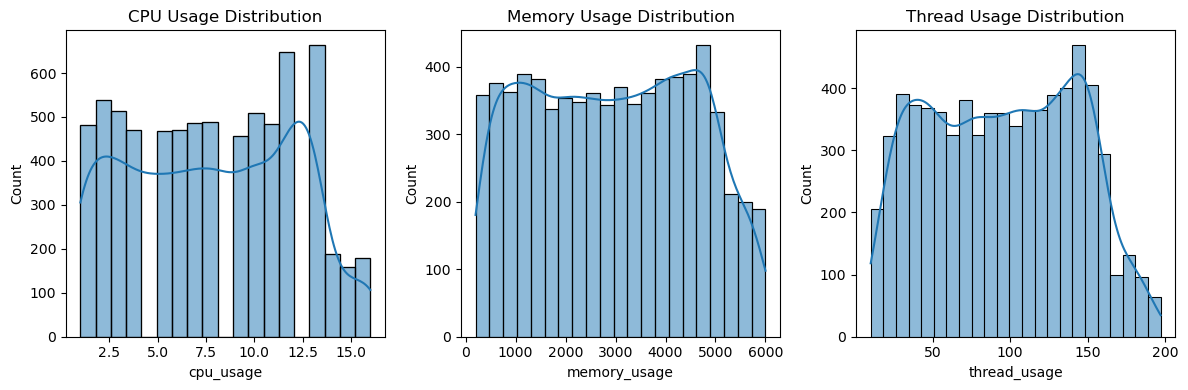

In [18]:
# Quick target distribution plots
fig, axes = plt.subplots(1, 3, figsize=(12,4))

sns.histplot(df["cpu_usage"], kde=True, ax=axes[0])
axes[0].set_title("CPU Usage Distribution")

sns.histplot(df["memory_usage"], kde=True, ax=axes[1])
axes[1].set_title("Memory Usage Distribution")

sns.histplot(df["thread_usage"], kde=True, ax=axes[2])
axes[2].set_title("Thread Usage Distribution")

plt.tight_layout()
plt.show()


In [19]:
# Baseline feature set
feature_cols = load_pct_cols + ["total_rps","avg_rt"] + rt_cols + rps_cols
X = df[feature_cols]
y_cpu = df["cpu_usage"]
y_mem = df["memory_usage"]
y_thread = df["thread_usage"]
X.head()

,api1_load_pct,api2_load_pct,api3_load_pct,api4_load_pct,api5_load_pct,total_rps,avg_rt,api1_rt,api2_rt,api3_rt,api4_rt,api5_rt,api1_rps,api2_rps,api3_rps,api4_rps,api5_rps
0,22.010870,23.913043,15.489130,17.391304,21.195652,368,94.0,81,84,118,114,73,81,88,57,64,78
1,22.500000,18.750000,17.083333,18.333333,23.333333,240,160.6,160,160,178,157,148,54,45,41,44,56
2,16.257669,17.484663,25.460123,25.460123,15.337423,326,134.8,163,159,93,89,170,53,57,83,83,50
3,21.865889,19.825073,19.825073,19.825073,18.658892,343,116.6,111,122,128,112,110,75,68,68,68,64
4,21.630094,23.824451,14.420063,18.181818,21.943574,319,126.2,114,97,160,150,110,69,76,46,58,70


In [20]:
# Train/test split
X_train, X_test, y_cpu_train, y_cpu_test, y_mem_train, y_mem_test, y_thread_train, y_thread_test = train_test_split(
    X, y_cpu, y_mem, y_thread, test_size=0.2, random_state=42
)

In [21]:
# Baseline Linear Regression pipelines
lin_pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LinearRegression())
])

lin_pipe.fit(X_train, y_cpu_train)
cpu_pred = lin_pipe.predict(X_test)

lin_pipe_mem = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LinearRegression())
])
lin_pipe_mem.fit(X_train, y_mem_train)
mem_pred = lin_pipe_mem.predict(X_test)

lin_pipe_thread = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LinearRegression())
])
lin_pipe_thread.fit(X_train, y_thread_train)
thread_pred = lin_pipe_thread.predict(X_test)

def report_metrics(y_true, y_pred, label):
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    print(f"{label} -> RMSE: {rmse:.3f}, MSE: {mse:.3f}")

report_metrics(y_cpu_test, cpu_pred, "CPU LinearRegression")
report_metrics(y_mem_test, mem_pred, "Memory LinearRegression")
report_metrics(y_thread_test, thread_pred, "Thread LinearRegression")

CPU LinearRegression -> RMSE: 0.350, MSE: 0.122
Memory LinearRegression -> RMSE: 164.237, MSE: 26973.821
Thread LinearRegression -> RMSE: 7.993, MSE: 63.886


In [22]:
# 5-fold CV 
cv = KFold(n_splits=5, shuffle=True, random_state=42)

cpu_cv_mse = -cross_val_score(lin_pipe, X, y_cpu, scoring="neg_mean_squared_error", cv=cv)
mem_cv_mse = -cross_val_score(lin_pipe_mem, X, y_mem, scoring="neg_mean_squared_error", cv=cv)
thread_cv_mse = -cross_val_score(lin_pipe_thread, X, y_thread, scoring="neg_mean_squared_error", cv=cv)

cpu_cv_rmse = np.sqrt(cpu_cv_mse)
mem_cv_rmse = np.sqrt(mem_cv_mse)
thread_cv_rmse = np.sqrt(thread_cv_mse)

print("CPU CV RMSE mean=", round(cpu_cv_rmse.mean(), 3))
print("MEM CV RMSE mean=", round(mem_cv_rmse.mean(), 3))
print("THREAD CV RMSE mean=", round(thread_cv_rmse.mean(), 3))


CPU CV RMSE mean= 0.352
MEM CV RMSE mean= 165.245
THREAD CV RMSE mean= 7.971


In [23]:
# Coefficients (impact analysis for report)
cpu_model = lin_pipe.named_steps["model"]
mem_model = lin_pipe_mem.named_steps["model"]
thread_model = lin_pipe_thread.named_steps["model"]

cpu_coef = pd.Series(cpu_model.coef_, index=feature_cols).sort_values(key=np.abs, ascending=False)
mem_coef = pd.Series(mem_model.coef_, index=feature_cols).sort_values(key=np.abs, ascending=False)
thread_coef = pd.Series(thread_model.coef_, index=feature_cols).sort_values(key=np.abs, ascending=False)

print("Top CPU drivers:")
print(cpu_coef)

print("Top Memory drivers:")
print(mem_coef)

print("Top Thread drivers:")
print(thread_coef)


Top CPU drivers:
api5_rt          0.880158
api1_rt          0.854300
api2_rt          0.833739
avg_rt           0.625259
api2_rps        -0.411963
api5_rps        -0.294978
api1_rps        -0.282419
total_rps       -0.241150
api4_rt         -0.195565
api3_rt         -0.149127
api4_rps         0.133489
api4_load_pct   -0.058205
api3_load_pct    0.054178
api2_load_pct    0.044247
api1_load_pct   -0.026718
api5_load_pct   -0.011278
api3_rps         0.008052
dtype: float64
Top Memory drivers:
api3_rt          538.321845
api4_rt          516.185912
avg_rt           234.961631
api3_rps        -200.446722
api4_rps        -193.570909
api1_rt          -95.452378
total_rps        -85.966174
api2_rt          -60.606500
api5_rt          -41.475507
api1_rps          32.293586
api2_rps          28.509753
api5_rps          22.942003
api3_load_pct      8.003607
api2_load_pct     -7.547759
api1_load_pct     -6.178088
api5_load_pct      4.663402
api4_load_pct     -1.669284
dtype: float64
Top Thread driv